# Chapter 7: Finetuning for Instruction Sets

In this final chapter, we dive into another kind of finetuning. Here we will train our model to follow instructions as opposed to last chapter where it acted as a classifier. Below is a template for our work:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/chapter-overview-1.webp?1" width=500px>

Here are the libraries required in this chapter

In [2]:
import numpy
import tiktoken
import urllib
import json
import torch
import os

## 7.1: Dataset Preparation

We work on a dataset prepared by the author.

In [3]:
def download_and_load_file(file_path, url):

    if not os.path.exists(file_path): # If the file does not exist create it and store data from url in it. If it exists do nothing
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)

    with open(file_path, "r", encoding="utf-8") as file: # reading from the file
        data = json.load(file)

    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url) 
print("Number of entries:", len(data))

Number of entries: 1100


data is list of samples containing a Instruction, Input and Response. The Input might be empty in cases where it is contained within the Instruction

In [4]:
print(data[0])
print(data[2])

{'instruction': 'Evaluate the following phrase by transforming it into the spelling given.', 'input': 'freind --> friend', 'output': 'The spelling of the given phrase "freind" is incorrect, the correct spelling is "friend".'}
{'instruction': 'Convert 45 kilometers to meters.', 'input': '', 'output': '45 kilometers is 45000 meters.'}


There are broadly 2 ways to format the input to the LLM. Alpaca and Phi-3, which are as in the image below. We will work on the former format.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/prompt-style.webp?1" width=500px>

In [5]:
def prep_sample(sample):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{sample['instruction']}"
    )

    input_text = f"\n\n### Input:\n{sample['input']}" if sample["input"] else ""

    return instruction_text + input_text

A completely formatted entry would look like:

In [6]:
print(prep_sample(data[0]) + f"\n\n### Response:\n{data[0]['output']}")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Evaluate the following phrase by transforming it into the spelling given.

### Input:
freind --> friend

### Response:
The spelling of the given phrase "freind" is incorrect, the correct spelling is "friend".


One without input field:

In [7]:
print(prep_sample(data[2]) + f"\n\n### Response:\n{data[2]['output']}")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert 45 kilometers to meters.

### Response:
45 kilometers is 45000 meters.


Partitioning samples:

In [8]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)    
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## 7.2: More Formatting

- We tackle this dataset batching in several steps, as summarized in the figure below

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/detailed-batching.webp?1" width=500px>

We begin by creating an InstructionDataset class, which will handle pretokenising all our entries

In [9]:
tokeniser = tiktoken.get_encoding("gpt2")

class InstructionDataset(torch.utils.data.Dataset):

    def __init__(self, data, tokeniser : tiktoken.Encoding):
        super().__init__()
        self.encoded_entries = []

        for entry in data:
            instr_plus_inp = prep_sample(entry)
            resp = f"\n\n### Response: \n{entry['output']}"
            self.encoded_entries.append(tokeniser.encode(instr_plus_inp+resp))
        
    def __getitem__(self, index):
        return self.encoded_entries[index]
    
    def __len__(self):
        return len(self.encoded_entries)

Next, we pad all encoded entries to have the same length, which is required when we want to train in batches

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/padding.webp" width=500px>

In [10]:
def collate_v1(batch, padding_token=50256, device="cpu"):
    max_len = max(len(x) for x in batch) + 1
    padded_plus_tensored = []

    for entry in batch:
        copy = entry.copy()
        copy.append(padding_token)
        copy += [padding_token]*(max_len - len(copy))

        padded_plus_tensored.append(torch.tensor(copy[:-1]))

    return torch.stack(padded_plus_tensored).to(device)

In [11]:
# TESTING

inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(collate_v1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


Next, we must prepare the target IDs as well.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/batching-step-4.webp?1" width=500px>

Above, we only returned the inputs to the LLM; however, for LLM training, we also need the target values. Similar to pretraining an LLM, the targets are the inputs shifted by 1 position to the right, so the LLM learns to predict the next token

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/inputs-targets.webp?1" width=400px>

To recap a bit, target_1[0] is predicted based upon the context vector input_1[0]. Iteratively, target[i+1] is predicted by entering output[i] into the model, and then choosing the token with the highest value in the out_layer.

In [12]:
def collate_v2(batch, padding_token = 50256, device = "cpu"):
    max_len = max(len(x) for x in batch) + 1
    padded_plus_tensored_inputs = []
    outputs = []

    for entry in batch:
        copy = entry.copy()
        copy.append(padding_token)
        copy += [padding_token]*(max_len - len(copy))

        outputs.append(torch.tensor(copy[1:]))
        padded_plus_tensored_inputs.append(torch.tensor(copy[:-1]))

    return torch.stack(padded_plus_tensored_inputs).to(device), torch.stack(outputs).to(device)

In [13]:
# TESTING

inputs, targets = collate_v2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


Now, we look at the concept of index ignoring, which allows us to ignore padding values in loss function

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/batching-step-5.webp?1" width=500px>

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/ignore-index.webp?1" width=500px>

In [14]:
def collate_fn(batch, padding_token = 50256, device = "cpu", allowed_max_length = None):
    max_len = max(len(x)+1 for x in batch)
    padded_plus_tensored_inputs = []
    outputs = []

    for entry in batch:
        copy = entry.copy()
        copy.append(padding_token)
        copy += [padding_token]*(max_len - len(copy))

        inputs = torch.tensor(copy[:-1])
        targets = torch.tensor(copy[1:])

        mask = targets == padding_token
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = -100
        
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        outputs.append(targets)
        padded_plus_tensored_inputs.append(inputs)

    return torch.stack(padded_plus_tensored_inputs).to(device), torch.stack(outputs).to(device)



In [15]:
# TESTING

inputs, targets = collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


Why is this beneficial?

In [16]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])

loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [17]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


The added example affected the loss

In [18]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


Adding -100 as the target exempts that case from the loss function, so the function value reverts back to the original value

By default, PyTorch has the `cross_entropy(..., ignore_index=-100)` setting to ignore examples corresponding to the label -100

However, we don't want to ignore the first instance of the end-of-text (padding) token (50256) because it can help signal to the LLM when the response is complete

## 7.3: Creating Dataloaders

In [19]:
from functools import partial

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

collate_fn_final = partial(                           ## Creates a new function with those arguments pre filled
    collate_fn,
    device=device,
    allowed_max_length=1024
)

In [20]:
from torch.utils.data import DataLoader


num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokeniser)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=collate_fn_final,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers 
)

val_dataset = InstructionDataset(val_data, tokeniser)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=collate_fn_final,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokeniser)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=collate_fn_final,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [21]:
print("Train loader:")
torch.manual_seed(123)
for i, (inputs, targets) in enumerate(train_loader):
    print(inputs.shape, targets.shape)


Train loader:
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 74]) torch.Size([8, 74])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 81]) torch.Size([8, 81])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 78]) torch.Size([8, 78])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 84]) torch.Size([8, 84])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 81]) torch.Size([8, 81])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 69]) torch.

## 7.4: Loading Pre-trained LLM

In [22]:
from gpt_download import download_and_load_gpt2
from GPT_Classes import GPTModel, load_weights_into_gpt
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch04 import GPTModel
# from llms_from_scratch.ch05 import download_and_load_gpt2, load_weights_into_gpt


BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2\355M\checkpoint
File already exists and is up-to-date: gpt2\355M\encoder.json
File already exists and is up-to-date: gpt2\355M\hparams.json
File already exists and is up-to-date: gpt2\355M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\355M\model.ckpt.index
File already exists and is up-to-date: gpt2\355M\model.ckpt.meta
File already exists and is up-to-date: gpt2\355M\vocab.bpe


GPTModel(
  (token_emb): Embedding(50257, 1024)
  (positional_emb): Embedding(1024, 1024)
  (dropper): Dropout(p=0.0, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attention_block): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (Dropper): Dropout(p=0.0, inplace=False)
      (ffn): FeedForward(
        (op_pipeline): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
     

Let's see how our model fares without finetuning in these tasks

In [23]:
test_input = prep_sample(val_data[0])
print(test_input)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [24]:
from GPT_Classes import text_generater
from utils import text_to_tokens, tokens_to_text
model.to(torch.device("cuda"))
print(tokens_to_text(text_generater(model, text_to_tokens(test_input, tokeniser), BASE_CONFIG["context_length"], 35), tokeniser)[len(test_input):])



### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


## 7.5: Finetuning LLM on instruction data

In this section, we finetune the model. Note that we can reuse all the loss calculation and training functions that we used in previous chapters

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/chapter-overview-5.webp?1" width=500px>



In [25]:
from GPT_Classes import calc_loss_loader

model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 4.007907772064209
Validation loss: 3.9404552936553956


Now we use the same train_loop function defined before for finetuning. The reason the previous tools work is that, we can think as if the 2 classes got substituted by the 50257 tokens.

In [26]:
import time
from GPT_Classes import training_function
start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_losses, val_losses, tokens_seen = training_function(
    model, train_loader, val_loader, num_epochs,
    optimizer, device, 5, prep_sample(val_data[0]), tokeniser
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Epoch: 0 Step: 5 Training loss: 1.17169988155365 Validation Loss: 1.263249397277832 
Epoch: 0 Step: 10 Training loss: 1.0315786480903626 Validation Loss: 0.9551605463027955 
Epoch: 0 Step: 15 Training loss: 0.8049930691719055 Validation Loss: 0.9057514667510986 
Epoch: 0 Step: 20 Training loss: 0.8288710474967956 Validation Loss: 0.8888798713684082 
Epoch: 0 Step: 25 Training loss: 0.7455776691436767 Validation Loss: 0.8524720549583436 
Epoch: 0 Step: 30 Training loss: 0.7168393135070801 Validation Loss: 0.8281733751296997 
Epoch: 0 Step: 35 Training loss: 0.7570011973381042 Validation Loss: 0.8066344022750854 
Epoch: 0 Step: 40 Training loss: 0.7078364729881287 Validation Loss: 0.7977630019187927 
Epoch: 0 Step: 45 Training loss: 0.6603137135505677 Validation Loss: 0.7878545880317688 
Epoch: 0 Step: 50 Training loss: 0.6139037728309631 Validation Loss: 0.7774586796760559 
Epoch: 0 Step: 55 Training loss: 0.6483428120613098 Validation Loss: 0.7646095275878906 
Epoch: 0 Step: 60 Trainin

training is done, now we move on to evaluation

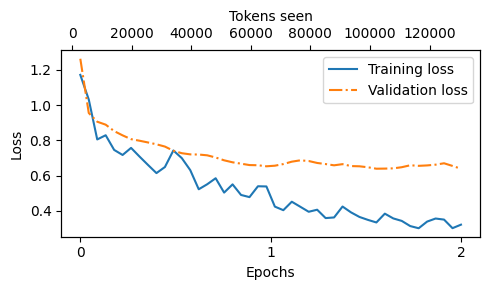

In [27]:
from utils import plot_losses

plot_losses(torch.linspace(0, num_epochs, len(train_losses)), tokens_seen, train_losses, val_losses)

testing it on sample

In [28]:
test_input = prep_sample(val_data[15])
print(tokens_to_text(text_generater(model, text_to_tokens(test_input, tokeniser), BASE_CONFIG["context_length"], 30), tokeniser))

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Classify the following statement into one of these labels: [positive, negative, neutral]

### Input:
My computer crashed.

### Response: 
Negative<|endoftext|>The following is an instruction that describes a task. Write a response that appropriately completes the request.



This is completely coherrent and correct

## 7.6: Extracting and Saving Responses

In [29]:
torch.manual_seed(123)

for entry in test_data[:3]:
    input = prep_sample(entry)
    generated_text = tokens_to_text(text_generater(model, text_to_tokens(input, tokeniser), BASE_CONFIG["context_length"], 30), tokeniser)

    cleaned_text = generated_text[len(input):].replace("### Response:", "").strip()
    cleaned_text = cleaned_text[:cleaned_text.find("<|endoftext|>")]

    print(input)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {cleaned_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud typically associated with thunderstorms is cumulus.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Pr

- We can see that model evaluation is not as straightforward as in the previous chapter, where we just had to calculate the percentage of correct spam/non-spam class labels to obtain the classification accuracy
- In practice, instruction-finetuned LLMs such as chatbots are evaluated via multiple approaches
  - short-answer and multiple choice benchmarks such as MMLU ("Measuring Massive Multitask Language Understanding", [https://arxiv.org/abs/2009.03300](https://arxiv.org/abs/2009.03300)), which test the knowledge of a model
  - human preference comparison to other LLMs, such as LMSYS chatbot arena ([https://arena.lmsys.org](https://arena.lmsys.org))
  - automated conversational benchmarks, where another LLM like GPT-4 is used to evaluate the responses, such as AlpacaEval ([https://tatsu-lab.github.io/alpaca_eval/](https://tatsu-lab.github.io/alpaca_eval/))

- In the next section, we will use an approach similar to AlpacaEval and use another LLM to evaluate the responses of our model; however, we will use our own test set instead of using a publicly available benchmark dataset
- For this, we add the model response to the `test_data` dictionary and save it as a `"instruction-data-with-response.json"` file for record-keeping so that we can load and analyze it in separate Python sessions if needed

In [31]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input = prep_sample(entry)
    generated_text = tokens_to_text(text_generater(model, text_to_tokens(input, tokeniser), BASE_CONFIG["context_length"], 30), tokeniser)

    cleaned_text = generated_text[len(input):].replace("### Response:", "").strip()
    cleaned_text = cleaned_text[:cleaned_text.find("<|endoftext|>")]

    test_data[i]['model_response'] = cleaned_text.strip()
    
with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)
    

100%|██████████| 110/110 [01:56<00:00,  1.06s/it]


The above code created a JSON file, now having the initial data plus the model response for each entry.

We also save the model to avoid training when we wish to use it again

In [32]:
import re


file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium355M-sft.pth


## 7.7: Evaluating Model Response

In this section, we use another better trained LLM, Ollama to evaluate our model. Ollama is an inference only C++ based LLM. This approach automates evaluation. After installing the option, running 'ollama run llama3' installs the 8 billion parameter model llama3. 

In [35]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")

if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


The above code checks, if Ollama is running as a process, which is crucial if we want to generate responses from it

To use it within Python we rely on the Ollama REST API. The function below is a pre-written function by the author of the reference, for inference

In [36]:
import urllib.request

def query_model(
    prompt,
    model="llama3",
    url="http://localhost:11434/api/chat"
):
    # Create the data payload as a dictionary
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {     # Settings below are required for deterministic responses
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }


    # Convert the dictionary to a JSON formatted string and encode it to bytes
    payload = json.dumps(data).encode("utf-8")

    # Create a request object, setting the method to POST and adding necessary headers
    request = urllib.request.Request(
        url,
        data=payload,
        method="POST"
    )
    request.add_header("Content-Type", "application/json")

    # Send the request and capture the response
    response_data = ""
    with urllib.request.urlopen(request) as response:
        # Read and decode the response
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]

    return response_data


model = "llama3"
result = query_model("What do Llamas eat?", model)
print(result)

Llamas are herbivores, which means they primarily feed on plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: High-quality hay, such as alfalfa or timothy hay, is a staple in a llama's diet. They enjoy the sweet taste and texture of fresh hay.
3. Grains: Llamas may receive grains like oats, barley, or corn as part of their daily ration. However, it's essential to provide these grains in moderation, as they can be high in calories.
4. Fruits and vegetables: Llamas enjoy a variety of fruits and veggies, such as apples, carrots, sweet potatoes, and leafy greens like kale or spinach.
5. Minerals: Llamas require access to mineral supplements, which help maintain their overall health and strong bones.

In the wild, llamas might also eat:

1. Leaves: They'll munch on leaves from trees and shrubs, like willow or cedar.
2. Bark: In some cases, llamas may eat the bark of

Below is our basic method of prompting the LLM and having it score our model

In [ ]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{prep_sample(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")

Function for scoring all entries in test_data and averaging scores:

In [38]:
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{prep_sample(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores


scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|██████████| 110/110 [09:11<00:00,  5.01s/it]

Number of scores: 110 of 110
Average score: 46.87



## 7.8: Conclusion

This marks the end of this project. We followed the roadmap below.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/final-overview.webp?1" width=500px>

And all of the stages have been explored :)